In [2]:
import librosa
from scipy.signal import butter, filtfilt
import numpy as np
import os
import matplotlib.pyplot as plt
import pandas as pd


In [3]:
dataset = '../EMOVO/'
actors = ['f1','f2','f3','m1','m2','m3']
files = []

for path in actors:
    actors_paths = dataset + path +'/'
    for file in os.listdir(actors_paths):
        if file.endswith(".wav"):
            files.append(actors_paths + file)

print(len(files))

588


we define a function to resample the audioFiles

In [21]:
def resample_audio(audio_path, ismono = True,  target_sr=22050):
    y, sr = librosa.load(audio_path, mono=ismono, sr=None)
    return y, sr

resample_audio(files[1])


(array([-0.00030518, -0.00041199,  0.        , ..., -0.00015259,
         0.00016785,  0.00015259], dtype=float32),
 48000)

In [22]:
resampled_files = []
for file in files:
    resampled_files.append(resample_audio(file)[0])

print(len(resampled_files))
resampled_files[0]



588


array([4.5776367e-04, 7.6293945e-05, 1.6784668e-04, ..., 3.6621094e-04,
       1.3732910e-04, 4.7302246e-04], dtype=float32)

now we define a function to reduce noise

In [23]:

from scipy.signal import butter, sosfilt, sosfreqz
def butter_bandpass(signal, fs, lowcut=100, highcut=8000, order=5):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    sos = butter(order, [low, high], btype='band', output='sos')

    return sosfilt(sos, signal)

In [7]:
def plot_frequency(y, sr):
    n = len(y)
    f = np.fft.fftfreq(n, 1/sr)
    Y = np.fft.fft(y)
    plt.plot(f, np.abs(Y))
    plt.xlabel('Frequency [Hz]')
    plt.ylabel('Magnitude')
    plt.show()


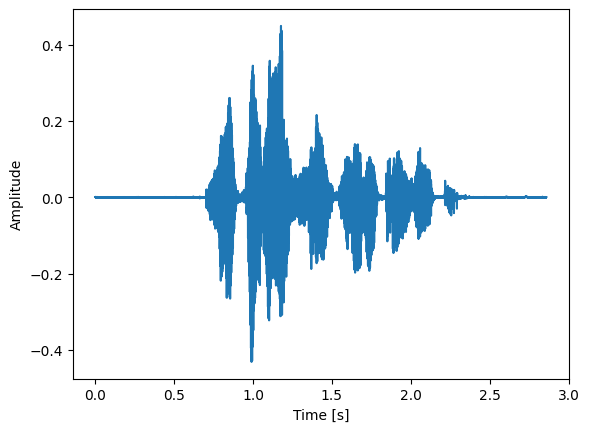

(137216,) (137216,)


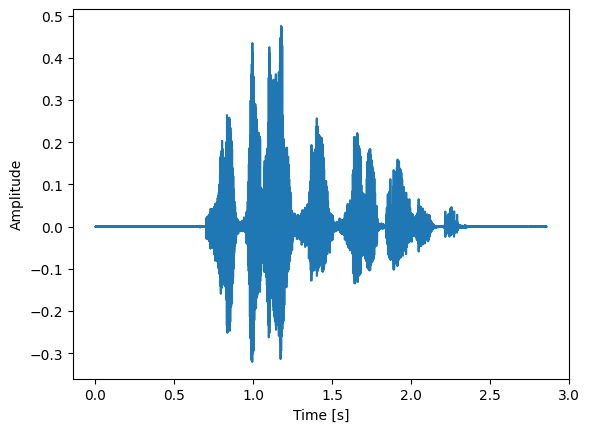

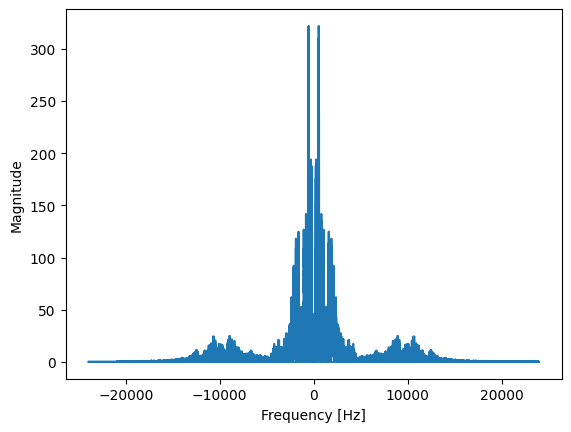

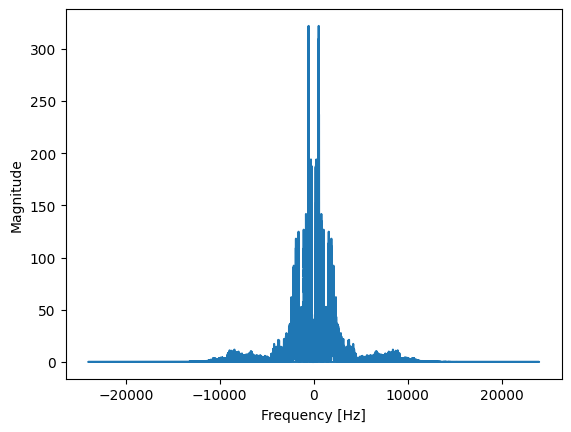

In [30]:
# lets try the function on one audio
fs = 48000
y = resampled_files[0]
t = np.linspace(0, len(y)/fs, len(y))
plt.plot(t, y)
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')
plt.show()
y_butter_filter = butter_bandpass(y, fs, lowcut=100, highcut=8000, order=5)
print(y_butter_filter.shape, y.shape)
plt.plot(t, y_butter_filter)
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')
plt.show()
plot_frequency(y, fs)
plot_frequency(y_butter_filter, fs)


import sounddevice as sd
sd.play(y, fs)
sd.wait()
sd.play(y_butter_filter, fs)


In [27]:
#now let's design a function that apply chebyshev filter in order to remove the noise
from scipy.signal import cheby1, sosfilt

def apply_chebyshev_filter(signal, fs, lowcut=100, highcut=8000, order=5, rp=5):
    low = lowcut / (0.5 * fs)
    high = highcut / (0.5 * fs)
    
    # Applica il filtro di Chebyshev
    sos = cheby1(order, rp, [low, high], btype='band', output='sos')
    filtered_signal = sosfilt(sos, signal)
    
    return filtered_signal



(137216,) (137216,)


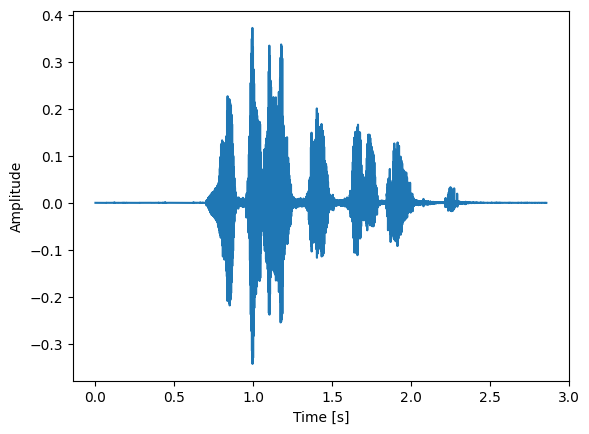

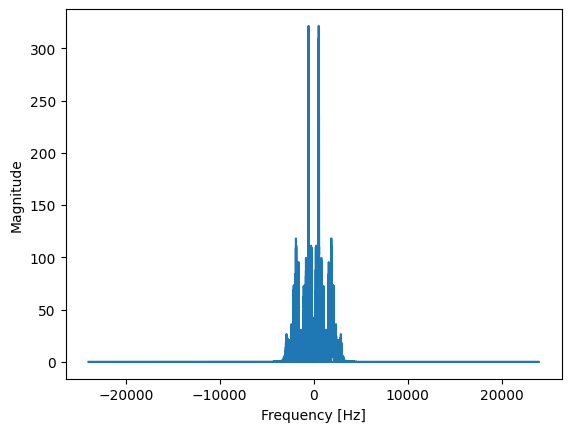

In [31]:
y_butter_chebyshev_filter = apply_chebyshev_filter(y, fs)
print(y_butter_chebyshev_filter.shape, y_butter_filter.shape)
plt.plot(t, y_butter_chebyshev_filter)
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')
plt.show()
plot_frequency(y_butter_chebyshev_filter, fs)

sd.play(y_butter_filter, fs)
sd.wait()
sd.play(y_butter_chebyshev_filter, fs)



In [15]:
def extract_pitch(y, sr):
    pitches, magnitudes = librosa.core.piptrack(y=y, sr=sr)
    pitch = []
    for i in range(0, len(pitches)):
        pitch.append(pitches[i][np.argmax(magnitudes[i])])
    return pitch

#we extract the pitch
pitch_y = extract_pitch(y, fs)
pitch_y_butter = extract_pitch(y_butter_filter, fs)



[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 155.26892, 163.56387, 176.82553, 177.93288, 197.57161, 202.74303, 219.79784, 229.15942, 232.8089, 252.76282, 263.06207, 267.39264, 284.3691, 292.23346, 298.84286, 315.72476, 323.96927, 328.61044, 343.80893, 357.88806, 367.08652, 377.68997, 387.40714, 394.70795, 409.41873, 420.8664, 426.77145, 442.91553, 457.2624, 459.2859, 474.73032, 487.91275, 498.25137, 505.96066, 511.91125, 529.7496, 539.7696, 549.75775, 556.41693, 571.8404, 586.7576, 591.7186, 600.72754, 616.1696, 622.4657, 638.9152, 649.0822, 0.0, 668.0445, 682.1753, 684.9563, 701.76776, 711.6764, 722.4293, 730.5285, 737.52277, 753.24115, 761.94196, 773.76483, 791.1662, 794.01715, 809.51855, 817.69446, 825.131, 841.4534, 853.85864, 862.88257, 867.9654, 882.09045, 889.3997, 909.63007, 915.7586, 931.11096, 932.4849, 945.3811, 953.38745, 971.62854, 979.8477, 990.19617, 999.9001, 1012.685, 1024.2384, 1033.8513, 1046.8098, 1053.2925, 1060.7292, 1072.0123, 1086.531, 